# Two-Stage NSBH Impact Test (Lognormal Geometric Efficiency, FJ_MAX = 10)

This notebook reproduces the two-stage shared-physics setup with **lognormal geometric efficiency** instead of fixed, and lets \f_j^{\mathrm{BNS}}\ explore values up to \..., 10\.

Workflow:
1. Stage 1 (BNS-only): infer \(A, L_0, \mu_E, \sigma_E, \theta_c^{\mathrm{BNS}}, f_j^{\mathrm{BNS}})\.
2. Freeze \(A, L_0, \mu_E, \sigma_E)\ to Stage-1 medians.
3. Stage 2 (BNS+NSBH): infer \(\theta_c^{\mathrm{BNS}}, \theta_c^{\mathrm{NSBH}}, f_j^{\mathrm{BNS}})\.
4. Diagnose geometric anti-correlation with angular-only quantities (lognormal), split by cuts \... f_j < 1\ and \... f_j > 1\.

In [3]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import emcee

import sys
sys.path.insert(0, '../..')

plt.style.use('../../configurations/style.mplstyle')
datafiles = Path('../../datafiles')

from src.nsbh.init import initialize_combined_simulation
from src.top_hat.montecarlo import (
    create_k_interpolator,
    compute_luminosity_distance,
    simplified_montecarlo,
    apply_detection_cuts,
    score_func_cvm,
    poiss_log,
    run_mcmc,
    check_and_resume_mcmc,
)
from src.top_hat.geometric_eff import (
    geometric_efficiency_fixed,
    create_geometric_efficiency_lognormal_interpolator,
)
from src.nsbh.montecarlo import GBM_EFF, FJ_NSBH_FIXED, N_MC_EVENTS
import src.init

print('Imports complete.')

Imports complete.


In [4]:
# Shared population setup
demo_params = {
    'alpha': -0.6,
    'beta_s': -2.5,
    'n': 2.0,
    'theta_c': 3.4,
    'theta_v_max': 10.0,
    'z_model': 'fiducial_delayed_A0.5',
}

FJ_MAX = 10.0
SIGMA_THETA_C = 0.5  # Lognormal width parameter (log10 space)

bns_params, nsbh_data, data_dict = initialize_combined_simulation(
    datafiles=datafiles,
    params=demo_params,
    size_test=2_000,
    nsbh_population='fiducial_delayed_cut',
    nsbh_alpha='A0.5',
)

k_interpolator = create_k_interpolator()
bns_distances = compute_luminosity_distance(bns_params.z_arr)
nsbh_distances = nsbh_data.distances

# Create lognormal geometric efficiency interpolator
geom_eff_interp = create_geometric_efficiency_lognormal_interpolator(
    sigma_theta_c=SIGMA_THETA_C,
    n_points=200,
    minimum_theta_c=1.0,
    maximum_theta_c=25.0,
)

print(f'FJ_MAX (BNS)   = {FJ_MAX}')
print(f'FJ_NSBH fixed  = {FJ_NSBH_FIXED}')
print(f'Lognormal width (log10 space) = {SIGMA_THETA_C}')
print(f'BNS population size  = {len(bns_params.z_arr)}')
print(f'NSBH population size = {len(nsbh_data.z_arr)}')
print(f'Observed yearly GRB rate = {bns_params.yearly_rate:.2f}')

Using redshift model: samples_fiducial_delayed_A0.5_BNSs_0.dat with 60187 BNSs.
Computed total merger rate: 60477.4 yr^-1 (local R_0 = 22.7 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Computed total merger rate: 18332.3 yr^-1 (local R_0 = 3.8 Gpc^-3 yr^-1) for component BHNSs
NSBH population: fiducial_delayed_cut / A0.5
  BHNSs local rate R_0 = 3.8 Gpc^-3 yr^-1
  BHNSs total rate     = 18332 yr^-1
  1-year z sample size = 18332
FJ_MAX (BNS)   = 10.0
FJ_NSBH fixed  = 1
Lognormal width (log10 space) = 0.5
BNS population size  = 60187
NSBH population size = 18332
Observed yearly GRB rate = 18.58


## Stage 1: BNS-only Free-Parameter Inference

Free parameters:
- \... A_{\mathrm{index}}, L_{L0}, L_{\mu_E}, \sigma_E\
- \... \theta_c^{\mathrm{BNS}}, f_j^{\mathrm{BNS}}\

Here \theta_c^{\mathrm{BNS}}\ is the **median** of the lognormal theta_c distribution.
Here \f_j^{\mathrm{BNS}}\ is allowed up to \FJ_MAX = 10\.

In [5]:
# ---- Stage 1 settings ----
N_PARAMS_1 = 6
N_WALKERS_1 = 24
N_STEPS_1 = 10_000

run_name_stage1 = 'two_stage_stage1_bns_only_lognormal_fjmax10'
out_dir_stage1 = src.init.create_run_dir(run_name_stage1, output_files_default='Output_files')
backend_path_stage1 = out_dir_stage1 / 'emcee.h5'

def log_likelihood_stage1_bns_only(thetas, n_events=N_MC_EVENTS):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, fj_bns = thetas
    grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]

    geom_eff_bns = geom_eff_interp(theta_c_bns)
    epsilon_bns = geom_eff_bns * fj_bns
    intrinsic_bns = epsilon_bns * len(bns_params.z_arr) * GBM_EFF

    bns_results = simplified_montecarlo(
        grb_thetas, n_events, bns_params, bns_distances, k_interpolator
    )
    bns_trig, bns_analysis = apply_detection_cuts(
        bns_results['p_flux'], bns_results['E_p_obs']
    )

    pflux_det = bns_results['p_flux'][bns_analysis]
    epeak_det = bns_results['E_p_obs'][bns_analysis]
    if len(pflux_det) <= 3:
        return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf

    logL_pflux = score_func_cvm(pflux_det, bns_params.pflux_data, bns_params.rng)
    logL_epeak = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)

    phys_eff_bns = np.sum(bns_trig) / n_events
    predicted_bns = intrinsic_bns * bns_params.triggered_years * phys_eff_bns

    observed_total = bns_params.yearly_rate * bns_params.triggered_years
    if predicted_bns <= 0:
        return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf

    logL_poisson = poiss_log(k=observed_total, mu=predicted_bns)
    logL_total = logL_pflux + logL_epeak + logL_poisson

    return logL_total, logL_pflux, logL_epeak, logL_poisson, predicted_bns

def log_prior_stage1(thetas):
    A_index, L_L0, L_mu_E, sigma_E, theta_c_bns, fj_bns = thetas

    if not (1.5 < A_index < 12):
        return -np.inf
    if not (-2 < L_L0 < 7):
        return -np.inf
    if not (0.1 < L_mu_E < 7):
        return -np.inf
    if not (0 < sigma_E < 2.5):
        return -np.inf
    if not (1 < theta_c_bns < 50):
        return -np.inf
    if not (0.01 < fj_bns <= FJ_MAX):
        return -np.inf

    return 0.0

def init_walkers_stage1(n_walkers, seed=123):
    rng = np.random.default_rng(seed)
    return np.column_stack([
        rng.uniform(2.0, 3.5, n_walkers),
        rng.uniform(2.0, 4.5, n_walkers),
        rng.uniform(1.5, 4.5, n_walkers),
        rng.uniform(0.2, 1.2, n_walkers),
        rng.uniform(3.0, 20.0, n_walkers),
        rng.uniform(0.1, min(FJ_MAX, 9.5), n_walkers),
    ])

def log_probability_stage1(thetas):
    lp = log_prior_stage1(thetas)
    if not np.isfinite(lp):
        return -np.inf, 0.0, 0.0, 0.0, 0.0

    ll = log_likelihood_stage1_bns_only(thetas=thetas, n_events=N_MC_EVENTS)
    if not np.isfinite(ll[0]):
        return -np.inf, 0.0, 0.0, 0.0, 0.0

    return lp + ll[0], ll[1], ll[2], ll[3], ll[4]

initial_pos_1, n_steps_rem_1, backend_1 = check_and_resume_mcmc(
    filename=backend_path_stage1,
    n_steps=N_STEPS_1,
    initialize_walkers_func=init_walkers_stage1,
    n_walkers=N_WALKERS_1,
)

print(f'Stage 1 backend: {backend_path_stage1}')
sampler_1 = run_mcmc(
    log_probability_func=log_probability_stage1,
    initial_walkers=initial_pos_1,
    n_iterations=n_steps_rem_1,
    n_walkers=N_WALKERS_1,
    n_params=N_PARAMS_1,
    backend=backend_1,
    blobs_dtype=[('l_pflux', float), ('l_epeak', float), ('l_poiss', float), ('mu_bns', float)],
)
print(f'Stage 1 done: {backend_1.iteration} total steps saved.')

Loading existing directory  : Output_files/two_stage_stage1_bns_only_lognormal_fjmax10
Already completed this run
Stage 1 backend: Output_files/two_stage_stage1_bns_only_lognormal_fjmax10/emcee.h5


0it [00:00, ?it/s]

Stage 1 done: 10000 total steps saved.


In [6]:
# Extract Stage 1 posteriors and freeze spectral parameters
burn_frac = 0.33
thin = 10

flat_1 = backend_1.get_chain(discard=int(backend_1.iteration * burn_frac), thin=thin, flat=True)

param_names_1 = ['A_index', 'L_L0', 'L_mu_E', 'sigma_E', 'theta_c_bns', 'fj_bns']
medians_1 = np.median(flat_1, axis=0)

spectral_fixed = medians_1[:4].copy()
theta_bns_stage1_med = medians_1[4]
fj_bns_stage1_med = medians_1[5]

print('Stage 1 posterior medians:')
for n, v in zip(param_names_1, medians_1):
    print(f'  {n:>12s} = {v:.4f}')

print('\nFixed spectral block for Stage 2:')
print(f'  A_index={spectral_fixed[0]:.4f}, L_L0={spectral_fixed[1]:.4f}, L_mu_E={spectral_fixed[2]:.4f}, sigma_E={spectral_fixed[3]:.4f}')

Stage 1 posterior medians:
       A_index = 3.3088
          L_L0 = 2.7005
        L_mu_E = 3.5406
       sigma_E = 0.4792
   theta_c_bns = 14.1869
        fj_bns = 1.1158

Fixed spectral block for Stage 2:
  A_index=3.3088, L_L0=2.7005, L_mu_E=3.5406, sigma_E=0.4792


## Stage 2: Add NSBH While Spectral Block Is Frozen

Free parameters now:
- \... \theta_c^{\mathrm{BNS}}\ (median of lognormal)
- \... \theta_c^{\mathrm{NSBH}}\ (median of lognormal)
- \... f_j^{\mathrm{BNS}}\, with \f_j^{\mathrm{BNS}} \leq FJ_MAX = 10\.

In [7]:
# ---- Stage 2 settings ----
N_PARAMS_2 = 3
N_WALKERS_2 = 24
N_STEPS_2 = 10_000

run_name_stage2 = 'two_stage_stage2_bns_plus_nsbh_lognormal_fixed_spectral_fjmax10'
out_dir_stage2 = src.init.create_run_dir(run_name_stage2, output_files_default='Output_files')
backend_path_stage2 = out_dir_stage2 / 'emcee.h5'

def log_likelihood_stage2_fixed_spectral(thetas, spectral_fixed, n_events=N_MC_EVENTS):
    theta_c_bns, theta_c_nsbh, fj_bns = thetas
    A_index, L_L0, L_mu_E, sigma_E = spectral_fixed
    grb_thetas = [A_index, L_L0, L_mu_E, sigma_E]

    geom_eff_bns = geom_eff_interp(theta_c_bns)
    geom_eff_nsbh = geom_eff_interp(theta_c_nsbh)

    epsilon_bns = geom_eff_bns * fj_bns
    epsilon_nsbh = geom_eff_nsbh * FJ_NSBH_FIXED

    intrinsic_bns = epsilon_bns * len(bns_params.z_arr) * GBM_EFF
    intrinsic_nsbh = epsilon_nsbh * len(nsbh_data.z_arr) * GBM_EFF

    bns_results = simplified_montecarlo(
        grb_thetas, n_events, bns_params, bns_distances, k_interpolator
    )
    bns_trig, bns_analysis = apply_detection_cuts(
        bns_results['p_flux'], bns_results['E_p_obs']
    )

    nsbh_results = simplified_montecarlo(
        grb_thetas, n_events, nsbh_data, nsbh_distances, k_interpolator, rng=bns_params.rng
    )
    nsbh_trig, nsbh_analysis = apply_detection_cuts(
        nsbh_results['p_flux'], nsbh_results['E_p_obs']
    )

    pflux_det = np.concatenate([
        bns_results['p_flux'][bns_analysis],
        nsbh_results['p_flux'][nsbh_analysis],
    ])
    epeak_det = np.concatenate([
        bns_results['E_p_obs'][bns_analysis],
        nsbh_results['E_p_obs'][nsbh_analysis],
    ])

    if len(pflux_det) <= 3:
        return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf

    logL_pflux = score_func_cvm(pflux_det, bns_params.pflux_data, bns_params.rng)
    logL_epeak = score_func_cvm(epeak_det, bns_params.epeak_data, bns_params.rng)

    phys_eff_bns = np.sum(bns_trig) / n_events
    phys_eff_nsbh = np.sum(nsbh_trig) / n_events

    predicted_bns = intrinsic_bns * bns_params.triggered_years * phys_eff_bns
    predicted_nsbh = intrinsic_nsbh * bns_params.triggered_years * phys_eff_nsbh
    predicted_total = predicted_bns + predicted_nsbh

    observed_total = bns_params.yearly_rate * bns_params.triggered_years
    if predicted_total <= 0:
        return -np.inf, -np.inf, -np.inf, -np.inf, -np.inf, -np.inf

    logL_poisson = poiss_log(k=observed_total, mu=predicted_total)
    logL_total = logL_pflux + logL_epeak + logL_poisson

    return logL_total, logL_pflux, logL_epeak, logL_poisson, predicted_bns, predicted_nsbh

def log_prior_stage2(thetas):
    theta_c_bns, theta_c_nsbh, fj_bns = thetas

    if not (1 < theta_c_bns < 50):
        return -np.inf
    if not (1 < theta_c_nsbh < 50):
        return -np.inf
    if not (0.01 < fj_bns <= FJ_MAX):
        return -np.inf

    return 0.0

def init_walkers_stage2(n_walkers, seed=321):
    rng = np.random.default_rng(seed)
    fj_low = max(0.05, fj_bns_stage1_med * 0.5)
    fj_high = min(FJ_MAX, max(fj_low + 0.05, fj_bns_stage1_med * 1.5))
    return np.column_stack([
        rng.uniform(max(1.2, theta_bns_stage1_med * 0.6), min(45.0, theta_bns_stage1_med * 1.4), n_walkers),
        rng.uniform(2.0, 25.0, n_walkers),
        rng.uniform(fj_low, fj_high, n_walkers),
    ])

def log_probability_stage2(thetas):
    lp = log_prior_stage2(thetas)
    if not np.isfinite(lp):
        return -np.inf, 0.0, 0.0, 0.0, 0.0, 0.0

    ll = log_likelihood_stage2_fixed_spectral(
        thetas=thetas,
        spectral_fixed=spectral_fixed,
        n_events=N_MC_EVENTS,
    )
    if not np.isfinite(ll[0]):
        return -np.inf, 0.0, 0.0, 0.0, 0.0, 0.0

    return lp + ll[0], ll[1], ll[2], ll[3], ll[4], ll[5]

initial_pos_2, n_steps_rem_2, backend_2 = check_and_resume_mcmc(
    filename=backend_path_stage2,
    n_steps=N_STEPS_2,
    initialize_walkers_func=init_walkers_stage2,
    n_walkers=N_WALKERS_2,
)

print(f'Stage 2 backend: {backend_path_stage2}')
sampler_2 = run_mcmc(
    log_probability_func=log_probability_stage2,
    initial_walkers=initial_pos_2,
    n_iterations=n_steps_rem_2,
    n_walkers=N_WALKERS_2,
    n_params=N_PARAMS_2,
    backend=backend_2,
    blobs_dtype=[('l_pflux', float), ('l_epeak', float), ('l_poiss', float), ('mu_bns', float), ('mu_nsbh', float)],
)
print(f'Stage 2 done: {backend_2.iteration} total steps saved.')

Loading existing directory  : Output_files/two_stage_stage2_bns_plus_nsbh_lognormal_fixed_spectral_fjmax10
Already completed this run
Stage 2 backend: Output_files/two_stage_stage2_bns_plus_nsbh_lognormal_fixed_spectral_fjmax10/emcee.h5


0it [00:00, ?it/s]

Stage 2 done: 10000 total steps saved.


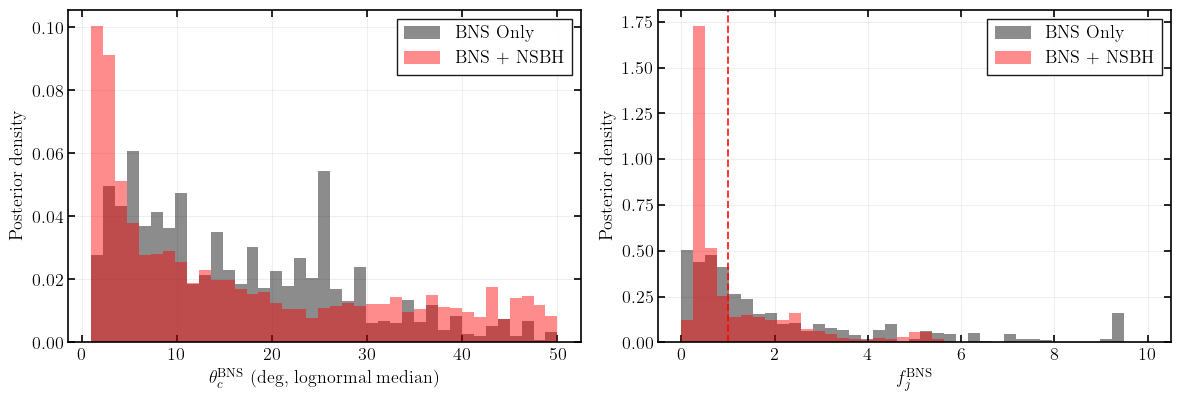

Median theta_c^BNS BNS Only      = 14.187 deg
Median theta_c^BNS BNS + NSBH    = 11.574 deg
Median fj^BNS BNS Only      = 1.116
Median fj^BNS BNS + NSBH    = 0.557


In [8]:
# Compare BNS angle and fj between Stage 1 and Stage 2
flat_2 = backend_2.get_chain(discard=int(backend_2.iteration * burn_frac), thin=thin, flat=True)

theta_bns_1 = flat_1[:, 4]
fj_bns_1 = flat_1[:, 5]

theta_bns_2 = flat_2[:, 0]
theta_nsbh_2 = flat_2[:, 1]
fj_bns_2 = flat_2[:, 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

bins_theta = np.linspace(1, 50, 40)
axes[0].hist(theta_bns_1, bins=bins_theta, density=True, alpha=0.45, label='BNS Only', color='black')
axes[0].hist(theta_bns_2, bins=bins_theta, density=True, alpha=0.45, label='BNS + NSBH', color='r')
axes[0].set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ (deg, lognormal median)')
axes[0].set_ylabel('Posterior density')
axes[0].legend()
axes[0].grid(True, alpha=0.2)

bins_fj = np.linspace(0, FJ_MAX, 40)
axes[1].hist(fj_bns_1, bins=bins_fj, density=True, alpha=0.45, label='BNS Only', color='black')
axes[1].hist(fj_bns_2, bins=bins_fj, density=True, alpha=0.45, label='BNS + NSBH', color='r')
axes[1].axvline(1.0, ls='--', lw=1.4, color='red', alpha=0.8)
axes[1].set_xlabel(r'$f_j^{\mathrm{BNS}}$')
axes[1].set_ylabel('Posterior density')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'Median theta_c^BNS BNS Only      = {np.median(theta_bns_1):.3f} deg')
print(f'Median theta_c^BNS BNS + NSBH    = {np.median(theta_bns_2):.3f} deg')
print(f'Median fj^BNS BNS Only      = {np.median(fj_bns_1):.3f}')
print(f'Median fj^BNS BNS + NSBH    = {np.median(fj_bns_2):.3f}')

## Angular-Only Geometric Anticorrelation with fj Cuts (Lognormal)

This diagnostic removes fj amplitudes and keeps only angular geometry (from lognormal distribution):
- \g_{\mathrm{ang,BNS}} = \text{geom\_eff\_interp}(\theta_c^{\mathrm{BNS}})\
- \g_{\mathrm{ang,NSBH}} = \text{geom\_eff\_interp}(\theta_c^{\mathrm{NSBH}})\

Then it compares the posterior anti-correlation in two subsets: \f_j < 1\ and \f_j > 1\.

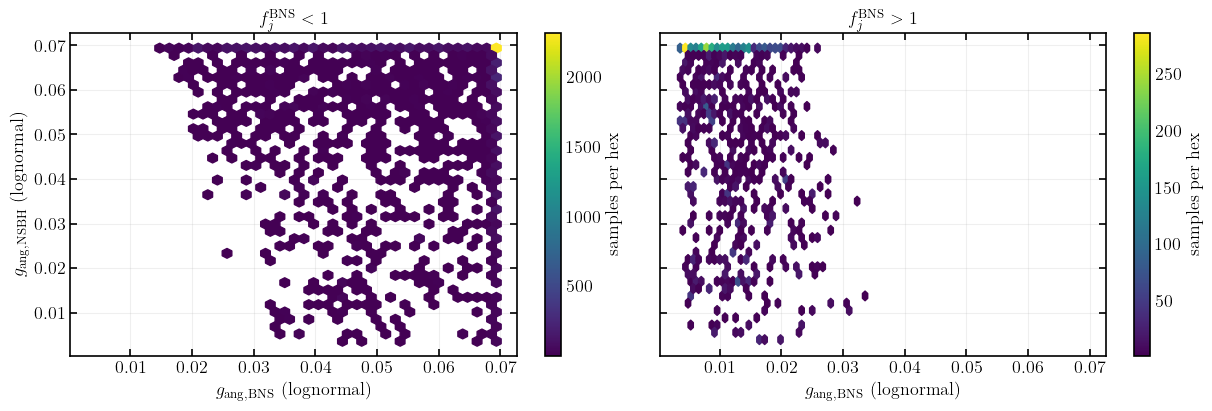

corr angular geometry | fj<1 : -0.06629920205158837
corr angular geometry | fj>1 : -0.24799843329034565


In [9]:
# Angular-only geometry (no fj prefactor)
g_ang_bns = np.array([geom_eff_interp(t) for t in theta_bns_2])
g_ang_nsbh = np.array([geom_eff_interp(t) for t in theta_nsbh_2])

mask_fj_lt1 = fj_bns_2 < 1.0
mask_fj_gt1 = fj_bns_2 > 1.0

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3), sharex=True, sharey=True)

subsets = [
    (mask_fj_lt1, r'$f_j^{\mathrm{BNS}} < 1$'),
    (mask_fj_gt1, r'$f_j^{\mathrm{BNS}} > 1$'),
]

for ax, (mask, title) in zip(axes, subsets):
    n_sel = np.sum(mask)
    if n_sel < 10:
        ax.text(0.5, 0.5, f'Not enough samples\n(N={n_sel})', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        ax.grid(True, alpha=0.2)
        continue

    hb = ax.hexbin(g_ang_bns[mask], g_ang_nsbh[mask], gridsize=35, mincnt=1, cmap='viridis')
    corr = np.corrcoef(g_ang_bns[mask], g_ang_nsbh[mask])[0, 1]
    ax.set_title(f'{title}')
    ax.grid(True, alpha=0.2)
    fig.colorbar(hb, ax=ax, label='samples per hex')

axes[0].set_xlabel(r'$g_{\mathrm{ang,BNS}}$ (lognormal)')
axes[1].set_xlabel(r'$g_{\mathrm{ang,BNS}}$ (lognormal)')
axes[0].set_ylabel(r'$g_{\mathrm{ang,NSBH}}$ (lognormal)')

plt.tight_layout()
plt.show()

if np.sum(mask_fj_lt1) > 1:
    print('corr angular geometry | fj<1 :', np.corrcoef(g_ang_bns[mask_fj_lt1], g_ang_nsbh[mask_fj_lt1])[0, 1])
if np.sum(mask_fj_gt1) > 1:
    print('corr angular geometry | fj>1 :', np.corrcoef(g_ang_bns[mask_fj_gt1], g_ang_nsbh[mask_fj_gt1])[0, 1])

In [10]:
theta_bns_1 = flat_1[:, 4]
fj_bns_1 = flat_1[:, 5]

theta_bns_2 = flat_2[:, 0]
theta_nsbh_2 = flat_2[:, 1]
fj_bns_2 = flat_2[:, 2]

g_bns_1 = np.array([geom_eff_interp(t) for t in theta_bns_1]) * fj_bns_1
g_bns_2 = np.array([geom_eff_interp(t) for t in theta_bns_2]) * fj_bns_2
g_nsbh_2 = np.array([geom_eff_interp(t) for t in theta_nsbh_2])

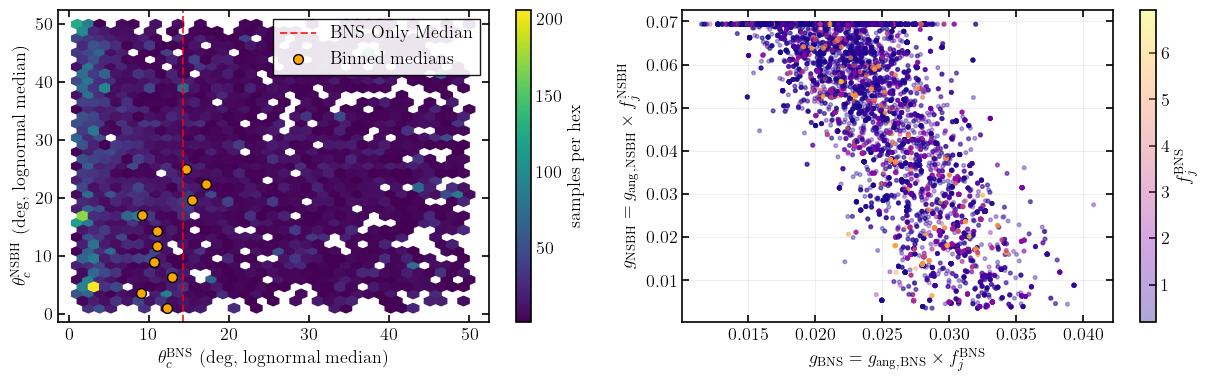

corr(theta_bns, theta_nsbh) = -0.0275
corr(g_bns, g_nsbh)         = -0.7703


In [11]:
g_bns_1 = np.array([geom_eff_interp(t) for t in theta_bns_1]) * fj_bns_1

g_bns_2 = np.array([geom_eff_interp(t) for t in theta_bns_2]) * fj_bns_2
g_nsbh_2 = np.array([geom_eff_interp(t) for t in theta_nsbh_2]) * FJ_NSBH_FIXED
g_total_2 = g_bns_2 + g_nsbh_2

corr_g = np.corrcoef(g_bns_2, g_nsbh_2)[0, 1]
corr_theta = np.corrcoef(theta_bns_2, theta_nsbh_2)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4))

ax = axes[0]
hb = ax.hexbin(theta_bns_2, theta_nsbh_2, gridsize=35, mincnt=1, cmap='viridis')
# MEDIAN BNS ONLY 
ax.axvline(np.median(theta_bns_1), ls='--', lw=1.4, color='red', alpha=0.8, label='BNS Only Median')
nsbh_bins = np.linspace(1, 25, 10)
medians_bns = []
for nb in nsbh_bins:
    theta_masks = (theta_nsbh_2 > nb - 2) & (theta_nsbh_2 < nb + 2)
    median_bns_in_bin = np.median(theta_bns_2[theta_masks])
    medians_bns.append(median_bns_in_bin)
ax.scatter(medians_bns, nsbh_bins, color='orange', s=50, edgecolor='k', label='Binned medians')
fig.colorbar(hb, ax=ax, label='samples per hex')
ax.set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ (deg, lognormal median)')
ax.set_ylabel(r'$\theta_c^{\mathrm{NSBH}}$ (deg, lognormal median)')
ax.legend()
ax = axes[1]
sc = ax.scatter(g_bns_2, g_nsbh_2, c=fj_bns_2, s=7, alpha=0.35, cmap='plasma')
fig.colorbar(sc, ax=ax, label=r'$f_j^{\mathrm{BNS}}$')
ax.set_xlabel(r'$g_{\mathrm{BNS}} = g_{\mathrm{ang,BNS}} \times f_j^{\mathrm{BNS}}$')
ax.set_ylabel(r'$g_{\mathrm{NSBH}} = g_{\mathrm{ang,NSBH}} \times f_j^{\mathrm{NSBH}}$')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'corr(theta_bns, theta_nsbh) = {corr_theta:.4f}')
print(f'corr(g_bns, g_nsbh)         = {corr_g:.4f}')

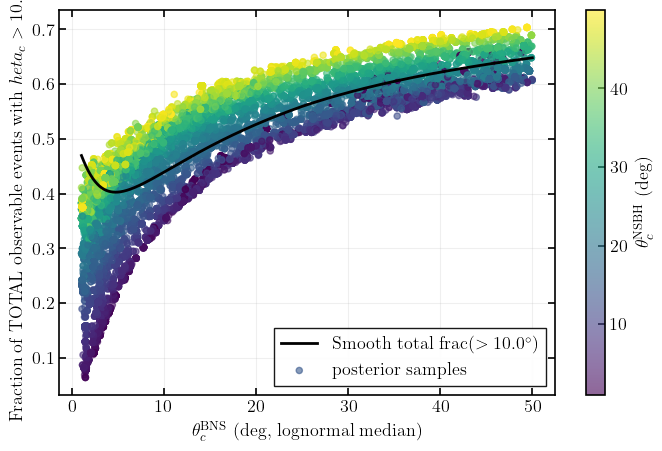

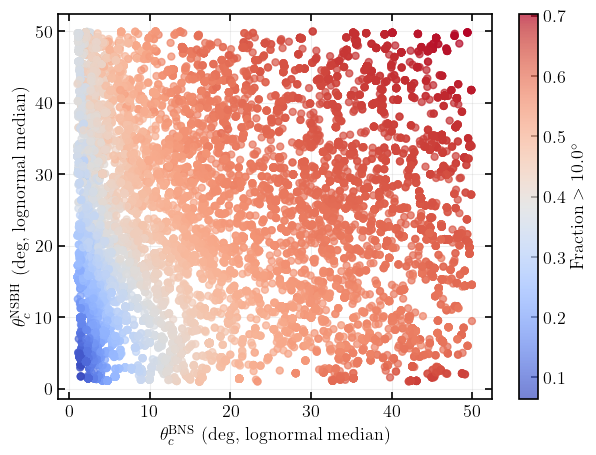

In [26]:
# Smooth fraction of TOTAL observable events above a threshold (vectorized)
theta_threshold = 10.0
# Truncation limits used by the interpolator
min_tc = 1.0
max_tc = 25.0
# lognormal natural-log shape from SIGMA_THETA_C (log10-space)
shape = SIGMA_THETA_C * np.log(10.0)
from scipy.stats import lognorm
# Precompute per-sample quantities for scatter overlay (exact, like your example)
total_bns_yr_samp = np.array([geom_eff_interp(t) for t in theta_bns_2]) * fj_bns_2 * len(bns_params.z_arr)
total_nsbh_yr_samp = np.array([geom_eff_interp(t) for t in theta_nsbh_2]) * FJ_NSBH_FIXED * len(nsbh_data.z_arr)
# per-sample tail fractions (BNS & NSBH)
cdf_max_bns_s = lognorm.cdf(max_tc, s=shape, scale=theta_bns_2)
cdf_min_bns_s = lognorm.cdf(min_tc, s=shape, scale=theta_bns_2)
cdf_thr_bns_s = lognorm.cdf(theta_threshold, s=shape, scale=theta_bns_2)
norm_bns_s = cdf_max_bns_s - cdf_min_bns_s
tail_bns_s = np.zeros_like(norm_bns_s)
m_ok = norm_bns_s > 1e-12
tail_bns_s[m_ok] = (cdf_max_bns_s[m_ok] - cdf_thr_bns_s[m_ok]) / norm_bns_s[m_ok]
# NSBH tail fractions per-sample
cdf_max_ns_s = lognorm.cdf(max_tc, s=shape, scale=theta_nsbh_2)
cdf_min_ns_s = lognorm.cdf(min_tc, s=shape, scale=theta_nsbh_2)
cdf_thr_ns_s = lognorm.cdf(theta_threshold, s=shape, scale=theta_nsbh_2)
norm_ns_s = cdf_max_ns_s - cdf_min_ns_s
tail_ns_s = np.zeros_like(norm_ns_s)
m_ok_ns = norm_ns_s > 1e-12
tail_ns_s[m_ok_ns] = (cdf_max_ns_s[m_ok_ns] - cdf_thr_ns_s[m_ok_ns]) / norm_ns_s[m_ok_ns]
# per-sample above-threshold counts and fraction (exact, like your loop example)
above_samp = total_bns_yr_samp * tail_bns_s + total_nsbh_yr_samp * tail_ns_s
total_events_samp = total_bns_yr_samp + total_nsbh_yr_samp
frac_samp_total = np.zeros_like(above_samp)
nz = total_events_samp > 0
frac_samp_total[nz] = above_samp[nz] / total_events_samp[nz]

# Build smooth curve vs theta_bns (use a representative fj for BNS and average NSBH contribution)
theta_grid = np.linspace(1.0, 50.0, 400)
# choose representative fj for smoothing: median of posterior fj samples
fj_rep = np.median(fj_bns_2)
# average NSBH per-source contribution (use posterior samples to get a mean per-NSBH-year factor)
mean_g_nsbh_per_source = np.mean(np.array([geom_eff_interp(t) for t in theta_nsbh_2]) * FJ_NSBH_FIXED)
# expected counts per theta_med on grid
g_bns_grid = geom_eff_interp(theta_grid) * fj_rep
expected_bns_yr_grid = g_bns_grid * len(bns_params.z_arr)
expected_nsbh_yr_grid = mean_g_nsbh_per_source * len(nsbh_data.z_arr)
# tail fraction for BNS as function of median theta on the grid
cdf_max_grid = lognorm.cdf(max_tc, s=shape, scale=theta_grid)
cdf_min_grid = lognorm.cdf(min_tc, s=shape, scale=theta_grid)
cdf_thr_grid = lognorm.cdf(theta_threshold, s=shape, scale=theta_grid)
norm_grid = cdf_max_grid - cdf_min_grid
tail_bns_grid = np.zeros_like(norm_grid)
okg = norm_grid > 1e-12
tail_bns_grid[okg] = (cdf_max_grid[okg] - cdf_thr_grid[okg]) / norm_grid[okg]
# estimate average NSBH tail fraction from posterior samples
mean_tail_nsbh = np.mean(tail_ns_s)
# combine to get smooth fraction of TOTAL events above threshold
above_grid = expected_bns_yr_grid * tail_bns_grid + expected_nsbh_yr_grid * mean_tail_nsbh
total_grid = expected_bns_yr_grid + expected_nsbh_yr_grid
frac_grid_total = np.zeros_like(above_grid)
nzg = total_grid > 0
frac_grid_total[nzg] = above_grid[nzg] / total_grid[nzg]

# Plot smooth total-fraction curve and posterior-sample points (which use exact per-sample fj & theta)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(theta_grid, frac_grid_total, color='k', lw=2, label=f'Smooth total frac($> {theta_threshold}^\circ$)')
sc = ax.scatter(theta_bns_2, frac_samp_total, c=theta_nsbh_2, cmap='viridis', s=20, alpha=0.6, label='posterior samples')
fig.colorbar(sc, ax=ax, label=r'$\theta_c^{\mathrm{NSBH}}$ (deg)')
ax.set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ (deg, lognormal median)')
ax.set_ylabel(f'Fraction of TOTAL observable events with $\theta_c > {theta_threshold}^\circ$')
ax.grid(True, alpha=0.2)
ax.legend()
plt.show()

# 2D scatter colored by exact per-sample fraction (as in your second plot)
fig2, ax2 = plt.subplots(figsize=(7, 5))
sc2 = ax2.scatter(theta_bns_2, theta_nsbh_2, c=frac_samp_total, cmap='coolwarm', alpha=0.7, s=25)
fig2.colorbar(sc2, ax=ax2, label=f'Fraction $> {theta_threshold}^\circ$')
ax2.set_xlabel(r'$\theta_c^{\mathrm{BNS}}$ (deg, lognormal median)')
ax2.set_ylabel(r'$\theta_c^{\mathrm{NSBH}}$ (deg, lognormal median)')
ax2.grid(True, alpha=0.2)
plt.show()